# Medical Cost Personal Insurance Dataset — Multiple Linear Regression

**Objective:** Predict individual medical insurance charges using Multiple Linear Regression, based on personal and health-related attributes.

**Dataset:** [Medical Cost Personal Datasets — Kaggle](https://www.kaggle.com/datasets/mirichoi0218/insurance)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
# Load the dataset
df = pd.read_csv("data/insurance.csv")
df.shape


(1338, 7)

In [3]:
# Display the first five records
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Feature identification:**

| Type | Features |
|---|---|
| Numerical features | `age`, `bmi`, `children` |
| Categorical features | `sex`, `smoker`, `region` |
| Target variable | `charges` |


## Task 2: Data Preprocessing

In [6]:
# Check for missing values
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 1


In [8]:
# Encode categorical variables
df_encoded = df.copy()

# Label Encoding for binary categorical columns
le_sex = LabelEncoder()
le_smoker = LabelEncoder()
df_encoded["sex"] = le_sex.fit_transform(df_encoded["sex"])       # female=0, male=1
df_encoded["smoker"] = le_smoker.fit_transform(df_encoded["smoker"])  # no=0, yes=1

# One-Hot Encoding for the multi-category 'region' column
df_encoded = pd.get_dummies(df_encoded, columns=["region"], drop_first=True)

df_encoded.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [9]:
# Split features (X) and target (y)
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size :", X_test.shape)


Training set size: (1070, 8)
Testing set size : (268, 8)


## Task 3: Model Development

In [10]:
# Build and train the Multiple Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict charges for the test dataset
y_pred = model.predict(X_test)

print("Model trained successfully.")


Model trained successfully.


In [11]:
# Inspect model coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Intercept:", model.intercept_)
coeff_df


Intercept: -11931.219050326667


,Feature,Coefficient
4,smoker,23651.128856
3,children,425.278784
2,bmi,337.092552
0,age,256.975706
1,sex,-18.591692
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## Task 4: Model Evaluation

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R\u00b2 Score: {r2:.4f}")


Mean Absolute Error (MAE): 4181.19
Mean Squared Error (MSE): 33596915.85
Root Mean Squared Error (RMSE): 5796.28
R² Score: 0.7836


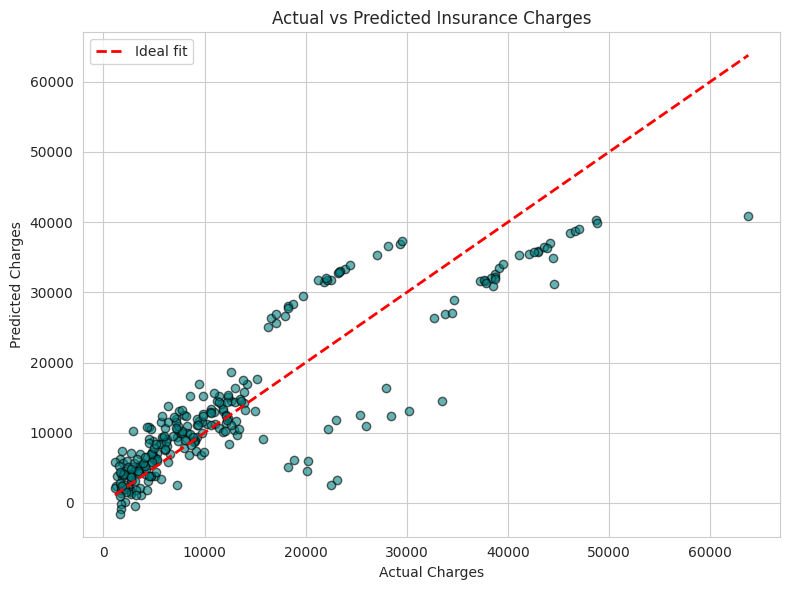

In [13]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color="teal", edgecolor="k")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label="Ideal fit")
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")
plt.legend()
plt.tight_layout()
plt.savefig("images/actual_vs_predicted.png", dpi=150)
plt.show()


**Observations:**

1. The model achieves a reasonably strong R² score, indicating that a large portion of the variance in insurance charges is explained by age, sex, BMI, children, smoker status, and region.
2. `smoker` status has by far the largest positive coefficient, confirming it is the strongest driver of higher insurance charges, followed by `age` and `bmi`.
3. The Actual vs Predicted plot shows points reasonably close to the ideal (red dashed) line for non-smokers, but the model under-predicts charges for high-cost smokers, suggesting a non-linear relationship that a simple linear model cannot fully capture.


## Task 5: Conclusion

The Multiple Linear Regression model was able to reasonably predict medical insurance charges using demographic and health-related features. Among all predictors, **smoking status** emerged as the most influential factor, followed by **age** and **BMI**, while **sex** and **region** had a comparatively minor effect on charges. Individuals who smoke and have a higher BMI tend to incur substantially higher medical costs, reflecting the real-world link between lifestyle/health risk factors and healthcare expenditure.

One key **limitation of Linear Regression** for this problem is its assumption of a linear relationship between the features and the target. In reality, the interaction between smoking and BMI produces a sharp, non-linear jump in charges for smokers with high BMI, which a linear model cannot capture well, leading to under-prediction for these high-cost cases. Non-linear models (e.g., Polynomial Regression, Random Forest, or Gradient Boosting) may better capture such interactions and improve predictive accuracy.
